# Visualizing Data — matplotlib discovery notebook

**Author(s):** Jaeseon Ha, Tanishq Kishnani  
**Created:** 2026-09-11  

Companion Jupyter notebook for Part 2 of hackathon26. It reproduces the three models
from the *MatPlotLib discovery* worksheet (`MatPlotLib discovery - filled.pdf` holds the
written answers) and practices the basics from the Dataquest Jupyter tutorial
(code cells, Markdown cells, `%matplotlib inline`, keyboard shortcuts, kernel restart, ...).

`scorecard.csv` is the *Most Recent Institution-Level Data* from
<https://collegescorecard.ed.gov/data/>; a local copy lives in the original `hackathon26/part2/` folder.

## Jupyter tutorial warm-up
A code cell: run it with **Shift+Enter**. `_` and `Out[n]` hold the last outputs.

In [1]:
print('Hello World!')

Hello World!


In [2]:
x = 3 * 7
x   # the value of the last expression is displayed without print()

21

Markdown cell practice: **bold**, *italic*, `code`, a list and a formula $y = \sin(2\pi x)$.

1. first
2. second

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import random
import csv

## Model 1 — Simple plot
Line 5–6 generate the data, line 7 plots it, lines 8–9 set the axes properties, line 10 displays the window.

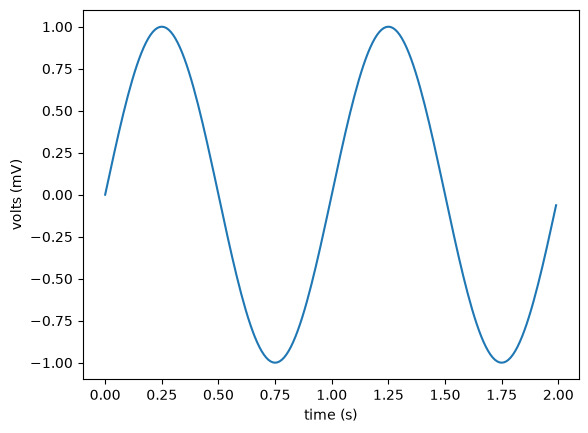

In [4]:
x = np.arange(0.0, 2.0, .01)   # 200 x values from 0 to 2 (exclusive)
y = np.sin(2 * np.pi * x)       # one cycle per unit of x -> two cycles
plt.plot(x, y)
plt.xlabel('time (s)')
plt.ylabel('volts (mV)')
plt.show()

**Q3** — one cycle only: change the stop value from 2.0 to 1.0.

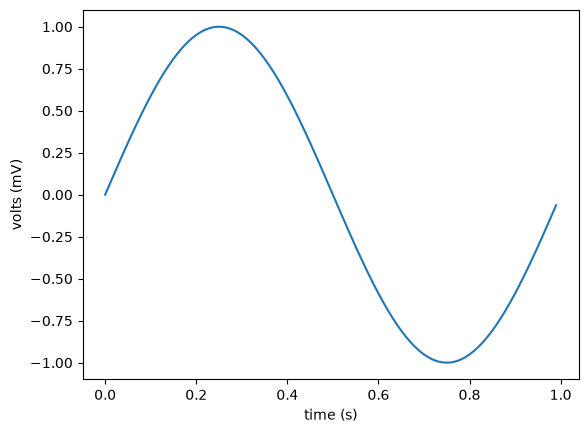

In [5]:
x = np.arange(0.0, 1.0, .01)
plt.plot(x, np.sin(2 * np.pi * x)); plt.xlabel('time (s)'); plt.ylabel('volts (mV)'); plt.show()

**Q4/Q6** — step 0.15 gives only 14 points, so the curve is jagged. **Q5** — `'o'` draws markers instead of a line.

14 points


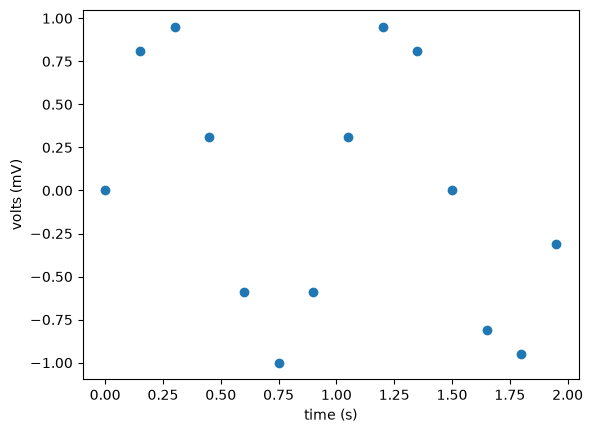

In [6]:
x = np.arange(0.0, 2.0, .15)
print(len(x), 'points')
plt.plot(x, np.sin(2 * np.pi * x), 'o'); plt.xlabel('time (s)'); plt.ylabel('volts (mV)'); plt.show()

**Q7** — $y = x^2 - 1$ from $-2$ to $+2$.

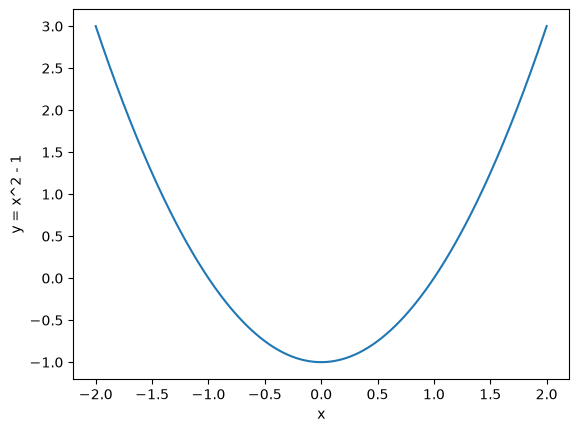

In [7]:
x = np.arange(-2.0, 2.01, .01)
plt.plot(x, x ** 2 - 1); plt.xlabel('x'); plt.ylabel('y = x^2 - 1'); plt.show()

## Model 2 — Histograms
`random.random()` returns floats in `[0.0, 1.0)`. `plt.hist` splits the range into 10 equal bins by default,
so with 100 values the bars are ~0.1 wide and their heights sum to 100.

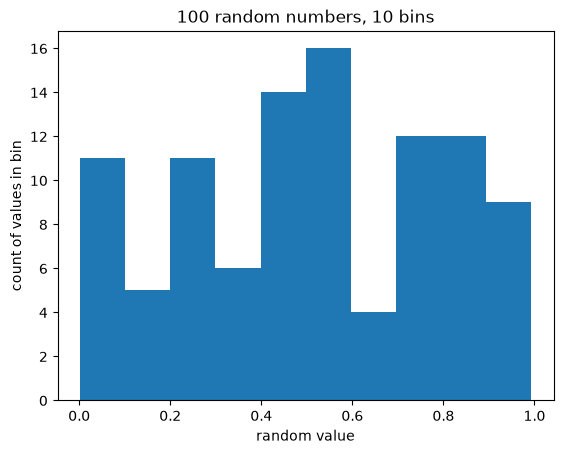

10 bars, width 0.099, heights sum to 100


In [8]:
def model_two(npts, bins=10):
    numbers = [random.random() for _ in range(npts)]
    counts, edges, _ = plt.hist(numbers, bins)
    plt.xlabel('random value'); plt.ylabel('count of values in bin')
    plt.title(f'{npts} random numbers, {bins} bins')
    plt.show()
    print(f'{len(counts)} bars, width {edges[1]-edges[0]:.3f}, heights sum to {counts.sum():.0f}')

random.seed(1)
model_two(100)

**Q12** — with more numbers the bars become nearly equal in height: the generator is uniform.

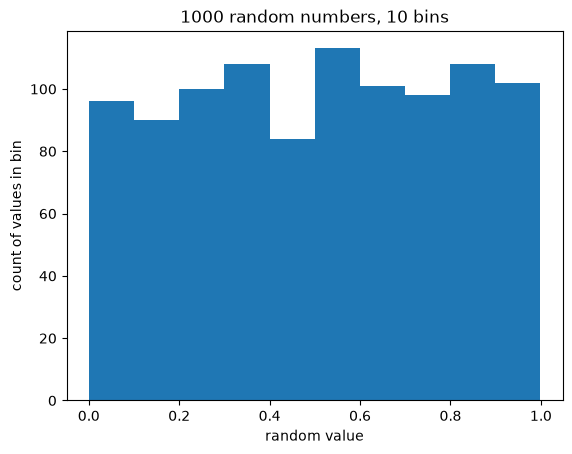

10 bars, width 0.100, heights sum to 1000


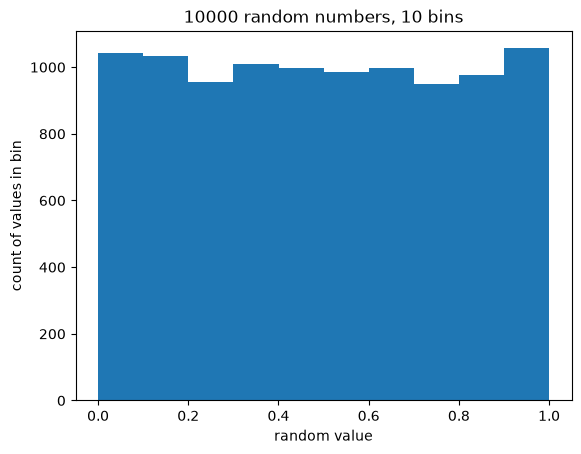

10 bars, width 0.100, heights sum to 10000


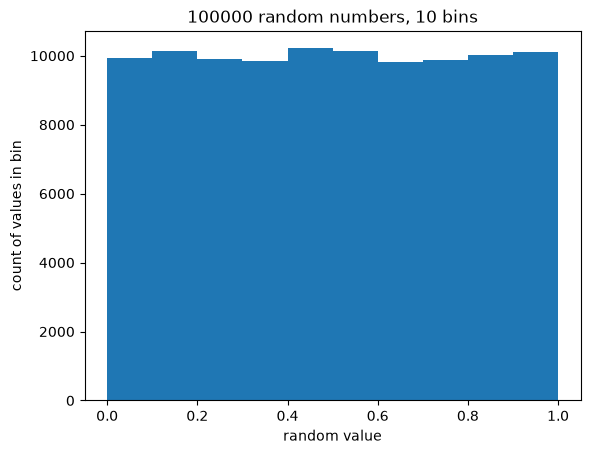

10 bars, width 0.100, heights sum to 100000


In [9]:
for n in (1000, 10000, 100000):
    model_two(n)

**Q13** — a second argument of 50 means 50 bins (each 0.02 wide).

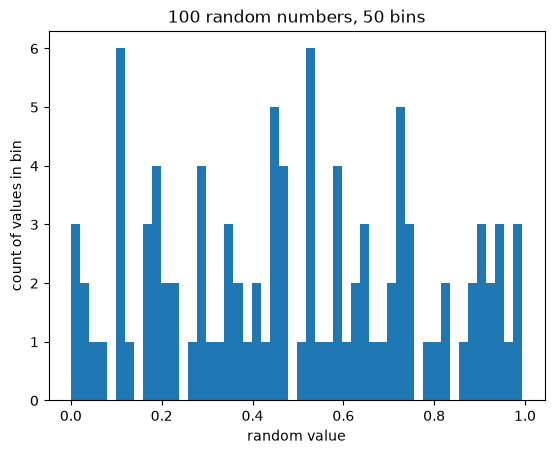

50 bars, width 0.020, heights sum to 100


In [10]:
model_two(100, 50)

## Model 3 — CSV data (College Scorecard)
Read the `UGDS` column (index 290, spreadsheet column KE) into a list of integers, skipping the `NA` rows.

In [11]:
infile = open('scorecard.csv', newline='', encoding='utf-8')
data = csv.reader(infile)
names = next(data)                       # header row
col = names.index('UGDS')
print('columns:', len(names), ' UGDS index:', col)

ugds, missing, rows = [], 0, 0
for row in data:                         # read the entire column into a list
    rows += 1
    if row[col] in ('NULL', 'NA', ''):
        missing += 1
    else:
        ugds.append(int(row[col]))       # strings -> integers
infile.close()
print(f'data rows: {rows}  integer values: {len(ugds)}  missing (NA): {missing}')
print(f'range: {min(ugds)} to {max(ugds)}')

columns: 3308  UGDS index: 290


data rows: 6273  integer values: 5478  missing (NA): 795
range: 0 to 163164


In [12]:
# Q19b: which school has the most undergraduates?
infile = open('scorecard.csv', newline='', encoding='utf-8')
data = csv.reader(infile); names = next(data)
best = max((row for row in data if row[col] not in ('NULL', 'NA', '')), key=lambda r: int(r[col]))
infile.close()
print(best[names.index('INSTNM')], int(best[col]))

Southern New Hampshire University 163164


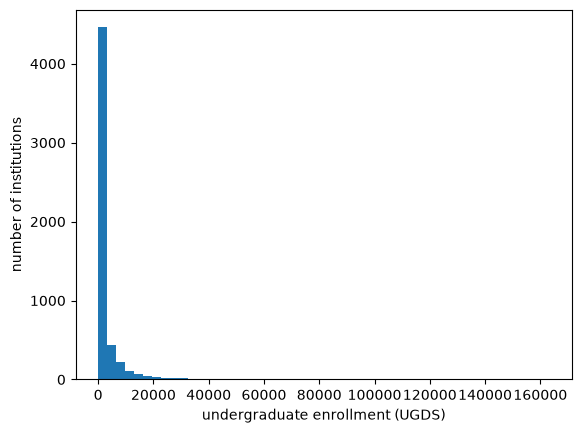

In [13]:
plt.hist(ugds, 50)
plt.xlabel('undergraduate enrollment (UGDS)'); plt.ylabel('number of institutions')
plt.show()

The distribution is extremely right-skewed: most institutions are small and a few online giants form a long tail. A log-scaled y axis makes the tail visible.

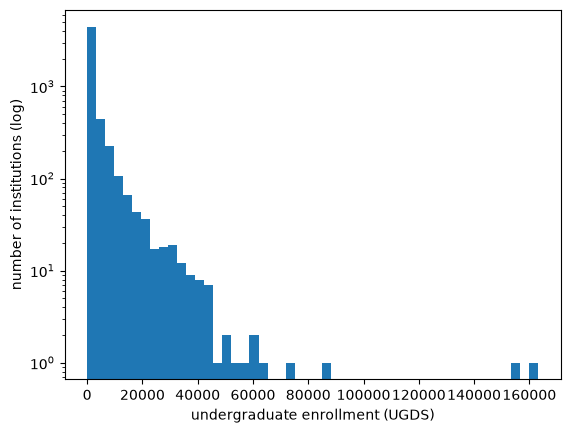

In [14]:
plt.hist(ugds, 50); plt.yscale('log')
plt.xlabel('undergraduate enrollment (UGDS)'); plt.ylabel('number of institutions (log)')
plt.show()

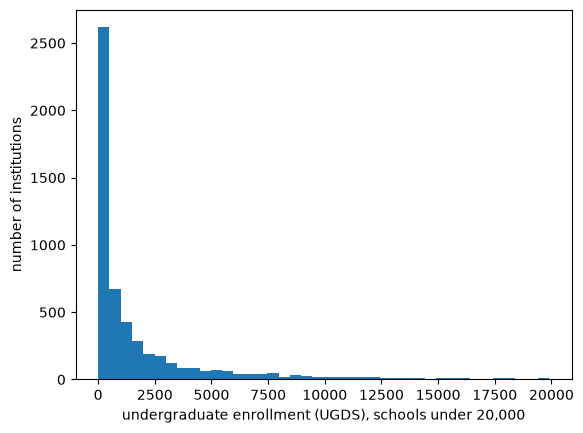

97.6% of schools have fewer than 20,000 undergraduates


In [15]:
# Zoom in on the typical school: only institutions with fewer than 20,000 undergrads
small = [v for v in ugds if v < 20000]
plt.hist(small, 40)
plt.xlabel('undergraduate enrollment (UGDS), schools under 20,000'); plt.ylabel('number of institutions')
plt.show()
print(f'{len(small)/len(ugds):.1%} of schools have fewer than 20,000 undergraduates')

## Q22 — other questions
* **Histogram**: distribution of admission rate (`ADM_RATE`), average SAT (`SAT_AVG`), or cost; overlay public vs private (`CONTROL`).
* **Scatter plot**: cost vs graduation rate, `ADM_RATE` vs `SAT_AVG`, enrollment vs median earnings.
* **Line chart**: cumulative share of enrollment after sorting schools by size, or yearly trends if several Scorecard years are combined.

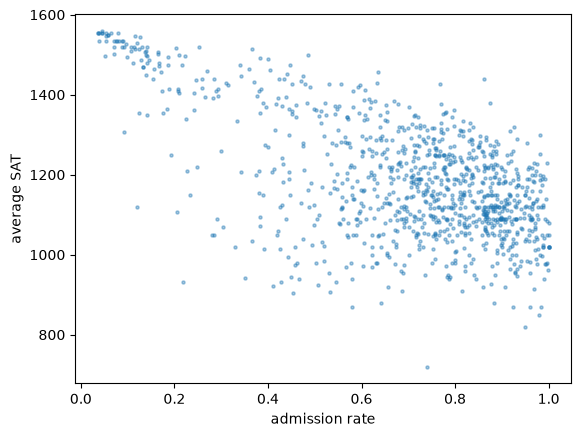

1037 institutions plotted


In [16]:
# Bonus scatter: admission rate vs average SAT (rows with both values)
infile = open('scorecard.csv', newline='', encoding='utf-8')
data = csv.reader(infile); names = next(data)
ia, isat = names.index('ADM_RATE'), names.index('SAT_AVG')
pts = [(float(r[ia]), float(r[isat])) for r in data
       if r[ia] not in ('NULL', 'NA', '') and r[isat] not in ('NULL', 'NA', '')]
infile.close()
plt.scatter([p[0] for p in pts], [p[1] for p in pts], s=5, alpha=0.4)
plt.xlabel('admission rate'); plt.ylabel('average SAT'); plt.show()
print(len(pts), 'institutions plotted')